In [1]:
print('hello')

hello


Epoch 01 | Train Loss: 0.96743 | Val Loss: 0.70882
Epoch 02 | Train Loss: 0.93446 | Val Loss: 0.67278
Epoch 03 | Train Loss: 0.90924 | Val Loss: 0.63756
Epoch 04 | Train Loss: 0.90346 | Val Loss: 0.64821
Epoch 05 | Train Loss: 0.90459 | Val Loss: 0.63922
Epoch 06 | Train Loss: 0.90038 | Val Loss: 0.63803
Epoch 07 | Train Loss: 0.88904 | Val Loss: 0.66366
Epoch 08 | Train Loss: 0.88100 | Val Loss: 0.68540
Epoch 09 | Train Loss: 0.86623 | Val Loss: 0.66830


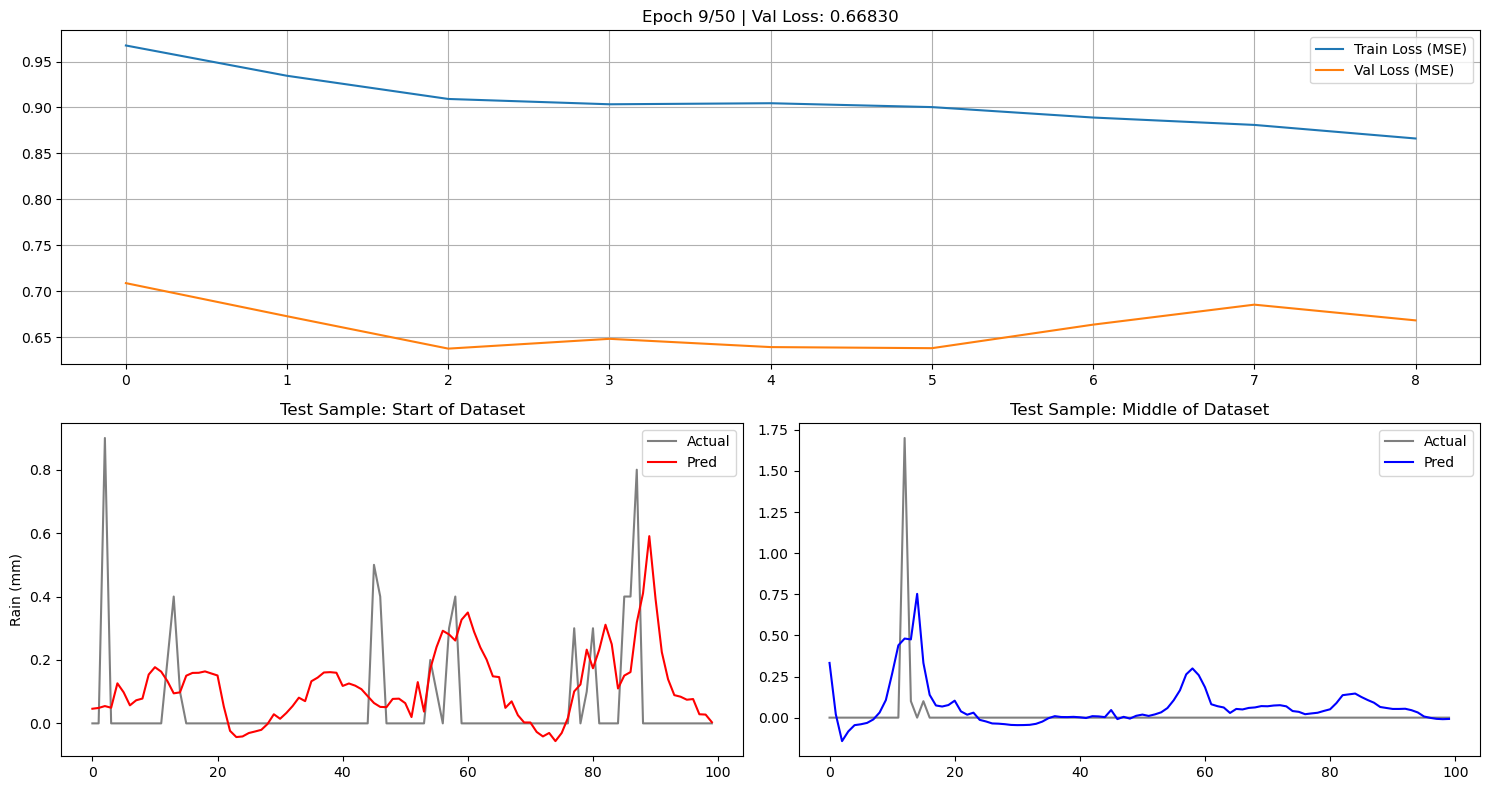

In [ ]:
# basic LSTM implimentation for rain prediction in the browser

# click in this cell and select the run/play button at the top to execute
# scroll to the bottom to see live training updates!

import micropip
await micropip.install(['pandas', 'numpy', 'scikit-learn', 'matplotlib'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyodide.http import pyfetch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from IPython.display import clear_output

%matplotlib inline

###############################
# layers and adam
################################

class Layer:
    def forward(self, x, training=True): pass
    def backward(self, grad): pass
    def params(self): return {}

class Sigmoid:
    def forward(self, x): return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))
    def backward(self, y): return y * (1.0 - y)

class Tanh:
    def forward(self, x): return np.tanh(np.clip(x, -50, 50))
    def backward(self, y): return 1.0 - y**2

class Dropout(Layer):
    def __init__(self, p=0.2, seed=0):
        self.p = p
        self.mask = None
        self.rng = np.random.default_rng(seed)

    def forward(self, x, training=True):
        if not training: return x
        self.mask = (self.rng.random(x.shape) > self.p) / (1.0 - self.p)
        return x * self.mask

    def backward(self, dy):
        return dy * self.mask, {}

class Dense(Layer):
    def __init__(self, input_dim, output_dim, seed=0):
        self.rng = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(input_dim)
        self.W = (self.rng.standard_normal((input_dim, output_dim)) * scale).astype(np.float32)
        self.b = np.zeros((output_dim,), dtype=np.float32)
        self.cache = None

    def forward(self, x, training=True):
        self.cache = x
        return x @ self.W + self.b

    def backward(self, dy):
        x = self.cache
        dW = x.T @ dy
        db = np.sum(dy, axis=0)
        dx = dy @ self.W.T
        return dx, {"W": dW, "b": db}

    def params(self):
        return {"W": self.W, "b": self.b}

# =========================================================
# NEW: Layer Normalization (per-sample, across features)
# =========================================================
class LayerNorm(Layer):
    def __init__(self, dim, eps=1e-5):
        self.eps = eps
        self.gamma = np.ones((dim,), dtype=np.float32)
        self.beta  = np.zeros((dim,), dtype=np.float32)
        self.cache = None

    def forward(self, x, training=True):
        # x: (B, F)
        mu = np.mean(x, axis=1, keepdims=True)
        var = np.mean((x - mu) ** 2, axis=1, keepdims=True)
        inv_std = 1.0 / np.sqrt(var + self.eps)
        x_hat = (x - mu) * inv_std
        y = x_hat * self.gamma + self.beta
        self.cache = (x_hat, inv_std)
        return y

    def backward(self, dy):
        # dy: (B, F)
        x_hat, inv_std = self.cache
        B, F = dy.shape

        dgamma = np.sum(dy * x_hat, axis=0).astype(np.float32)
        dbeta  = np.sum(dy, axis=0).astype(np.float32)

        dxhat = dy * self.gamma  # (B, F)

        # LayerNorm backward (per row):
        # dx = (1/F)*inv_std*(F*dxhat - sum(dxhat) - xhat*sum(dxhat*xhat))
        sum1 = np.sum(dxhat, axis=1, keepdims=True)                # (B,1)
        sum2 = np.sum(dxhat * x_hat, axis=1, keepdims=True)        # (B,1)
        dx = (inv_std / F) * (F * dxhat - sum1 - x_hat * sum2)     # (B,F)

        return dx.astype(np.float32), {"gamma": dgamma, "beta": dbeta}

    def params(self):
        return {"gamma": self.gamma, "beta": self.beta}


class LSTM(Layer):
    def __init__(self, input_dim, hidden_dim, seed=0):
        self.rng = np.random.default_rng(seed)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        concat_dim = input_dim + hidden_dim
        scale = 1.0 / np.sqrt(concat_dim)
        self.W = (self.rng.standard_normal((concat_dim, 4 * hidden_dim)) * scale).astype(np.float32)
        self.b = np.zeros((4 * hidden_dim,), dtype=np.float32)

        # NEW: layer norm on the pre-activations z (size 4H)
        self.ln = LayerNorm(dim=4 * hidden_dim, eps=1e-5)

        self.cache = None

    def forward(self, x, training=True):
        B, T, D = x.shape
        H = self.hidden_dim
        h, c = np.zeros((B, H), dtype=np.float32), np.zeros((B, H), dtype=np.float32)
        hs, cs, gates_cache, ln_cache_list = [], [], [], []

        sig = Sigmoid()
        th = Tanh()

        for t in range(T):
            xt = x[:, t, :]
            combined = np.hstack((xt, h))
            z_pre = combined @ self.W + self.b

            # NEW: layer norm here
            z = self.ln.forward(z_pre, training=True)
            ln_cache_list.append(self.ln.cache)

            zi, zf, zo, zg = np.split(z, 4, axis=1)
            i = sig.forward(zi)
            f = sig.forward(zf)
            o = sig.forward(zo)
            g = th.forward(zg)

            c = f * c + i * g
            h = o * th.forward(c)

            hs.append(h); cs.append(c)
            gates_cache.append((i, f, o, g, combined))

        # store LN caches per-timestep (because LN cache gets overwritten each call)
        self.cache = (x, hs, cs, gates_cache, ln_cache_list)
        return h

    def backward(self, dh_next):
        x, hs, cs, gates_cache, ln_cache_list = self.cache
        B, T, D = x.shape
        H = self.hidden_dim
        dW, db, dx = np.zeros_like(self.W), np.zeros_like(self.b), np.zeros_like(x)
        dh, dc = dh_next, np.zeros((B, H), dtype=np.float32)

        # NEW: accumulate LN grads
        dgamma = np.zeros_like(self.ln.gamma)
        dbeta  = np.zeros_like(self.ln.beta)

        sig = Sigmoid()
        th = Tanh()

        for t in reversed(range(T)):
            i, f, o, g, combined = gates_cache[t]
            c_prev = cs[t-1] if t > 0 else np.zeros((B, H), dtype=np.float32)

            tanh_c = th.forward(cs[t])
            dtanh_c = th.backward(tanh_c)

            do = dh * tanh_c
            dc += dh * o * dtanh_c

            df, di, dg, dc_prev = dc * c_prev, dc * g, dc * i, dc * f

            dz_norm = np.hstack((
                sig.backward(i) * di,
                sig.backward(f) * df,
                sig.backward(o) * do,
                th.backward(g) * dg
            )).astype(np.float32)  # gradient wrt normalized z

            # NEW: backprop through LN for this timestep
            self.ln.cache = ln_cache_list[t]
            dz_pre, ln_grads = self.ln.backward(dz_norm)
            dgamma += ln_grads["gamma"]
            dbeta  += ln_grads["beta"]

            dW += combined.T @ dz_pre
            db += np.sum(dz_pre, axis=0)

            dcombined = dz_pre @ self.W.T
            dx[:, t, :] = dcombined[:, :D]
            dh, dc = dcombined[:, D:], dc_prev

        return dx, {"W": dW, "b": db, "ln_gamma": dgamma, "ln_beta": dbeta}

    def params(self):
        # IMPORTANT: order matches grads order above (dict order is preserved)
        return {"W": self.W, "b": self.b, "ln_gamma": self.ln.gamma, "ln_beta": self.ln.beta}


class Adam:
    def __init__(self, params_list, lr=0.001):
        self.lr, self.beta1, self.beta2, self.eps, self.t = lr, 0.9, 0.099, 1e-8, 0
        self.m = [np.zeros_like(p) for p in params_list]
        self.v = [np.zeros_like(p) for p in params_list]
        self.params_list = params_list

    def step(self, grads_list):
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params_list, grads_list)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g**2)
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

################################
# data and normalization
#################################

async def get_hourly_weather():
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=33&longitude=-84&start_date=2022-01-01&end_date=2023-12-31&hourly=rain,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,vapor_pressure_deficit"
    print("Fetching Weather Data...")
    res = await pyfetch(url)
    data = await res.json()
    df = pd.DataFrame(data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    df = df.fillna(method='ffill').fillna(0)
    return df

df = await get_hourly_weather()

# --- Cyclical Time Features ---
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
df["day_sin"]  = np.sin(2 * np.pi * df.index.dayofyear / 366)
df["day_cos"]  = np.cos(2 * np.pi * df.index.dayofyear / 366)

TARGET_COL = "rain"
df['target'] = df[TARGET_COL].shift(-1)
df = df.dropna()

features = [c for c in df.columns if c != 'target']
X_raw = df[features].values
y_raw = df['target'].values.reshape(-1, 1)

#################################
# PCA and SCREE
#################################

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

pca = PCA()
pca.fit(X_scaled)
cum_variance = np.cumsum(pca.explained_variance_ratio_)
n_comps = np.argmax(cum_variance >= 0.95) + 1
X_pca = pca.transform(X_scaled)[:, :n_comps]

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cum_variance)+1), cum_variance, marker='.', linestyle='-')
plt.axhline(0.95, color='red', linestyle='--', label='95% Explained Variance')
plt.axvline(n_comps, color='green', linestyle='--', label=f'Selected Components ({n_comps})')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.legend()
plt.grid(True)
plt.show()

print(f"Selected top {n_comps} components.")

#######################################
# scaling targets and making sequences
#######################################

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_raw)

def make_sequences(data, targets, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(targets[i+seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

SEQ_LEN = 36
X_seq, y_seq = make_sequences(X_pca, y_scaled, SEQ_LEN)
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

########################
#training loop
########################

lstm_layer = LSTM(input_dim=n_comps, hidden_dim=64, seed=42)
dropout_layer = Dropout(p=0.3)
dense_layer = Dense(input_dim=64, output_dim=1, seed=42)

# NOTE: params now include LN gamma/beta automatically via lstm_layer.params()
all_params = list(lstm_layer.params().values()) + list(dense_layer.params().values())
optimizer = Adam(all_params, lr=0.002)

epochs = 35
batch_size = 64
history = {'train_loss': [], 'val_loss': []}
logs = []

for epoch in range(epochs):
    indices = np.arange(len(X_train))
    np.random.shuffle(indices)
    train_loss_accum = 0

    # --- TRAIN ---
    for start in range(0, len(indices), batch_size):
        idx = indices[start:start+batch_size]
        xb, yb = X_train[idx], y_train[idx]

        h = lstm_layer.forward(xb, training=True)
        h_drop = dropout_layer.forward(h, training=True)
        y_pred = dense_layer.forward(h_drop, training=True)

        diff = y_pred - yb
        loss = np.mean(diff**2)
        train_loss_accum += loss

        dy = 2.0 * diff / len(xb)
        dx_dense, grads_dense = dense_layer.backward(dy)
        dx_drop, _ = dropout_layer.backward(dx_dense)
        dx_lstm, grads_lstm = lstm_layer.backward(dx_drop)

        optimizer.step(list(grads_lstm.values()) + list(grads_dense.values()))

    # --- VALIDATE ---
    h_val = lstm_layer.forward(X_test, training=False)
    y_val_pred = dense_layer.forward(h_val, training=False)
    val_loss = np.mean((y_val_pred - y_test)**2)

    history['train_loss'].append(train_loss_accum / (len(indices)//batch_size))
    history['val_loss'].append(val_loss)

    log_msg = f"Epoch {epoch+1:02d} | Train Loss: {history['train_loss'][-1]:.5f} | Val Loss: {val_loss:.5f}"
    logs.append(log_msg)

    clear_output(wait=True)
    print("\n".join(logs))

    # live plots
    h_test = lstm_layer.forward(X_test, training=False)
    preds_scaled = dense_layer.forward(h_test, training=False)
    preds_mm = scaler_y.inverse_transform(preds_scaled)
    y_test_mm = scaler_y.inverse_transform(y_test)

    fig = plt.figure(figsize=(15, 8))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(history['train_loss'], label='Train Loss (MSE)')
    ax1.plot(history['val_loss'], label='Val Loss (MSE)')
    ax1.set_title(f"Epoch {epoch+1}/{epochs} | Val Loss: {val_loss:.5f}")
    ax1.legend()
    ax1.grid(True)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(y_test_mm[:100], label='Actual', color='black', alpha=0.5)
    ax2.plot(preds_mm[:100], label='Pred', color='red')
    ax2.set_title("Test Sample: Start of Dataset")
    ax2.set_ylabel("Rain (mm)")
    ax2.legend()

    mid = len(y_test_mm) // 2
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(y_test_mm[mid:mid+100], label='Actual', color='black', alpha=0.5)
    ax3.plot(preds_mm[mid:mid+100], label='Pred', color='blue')
    ax3.set_title("Test Sample: Middle of Dataset")
    ax3.legend()

    plt.tight_layout()
    plt.show()

print(f"Training Complete.")
print(f"Final Test MAE: {mean_absolute_error(y_test_mm, preds_mm):.2f} in mm of rainfall")

Epoch 01 | Train Loss: 1.00136 | Val Loss: 0.80758
Epoch 02 | Train Loss: 0.96597 | Val Loss: 0.79749
Epoch 03 | Train Loss: 0.93188 | Val Loss: 0.78773
Epoch 04 | Train Loss: 0.90453 | Val Loss: 0.78097
Epoch 05 | Train Loss: 0.87888 | Val Loss: 0.77721
Epoch 06 | Train Loss: 0.85773 | Val Loss: 0.77246
Epoch 07 | Train Loss: 0.83510 | Val Loss: 0.76617
Epoch 08 | Train Loss: 0.81763 | Val Loss: 0.76288
Epoch 09 | Train Loss: 0.80268 | Val Loss: 0.75939
Epoch 10 | Train Loss: 0.78745 | Val Loss: 0.75586
Epoch 11 | Train Loss: 0.77616 | Val Loss: 0.75465
Epoch 12 | Train Loss: 0.76639 | Val Loss: 0.75253
Epoch 13 | Train Loss: 0.75460 | Val Loss: 0.75201
Epoch 14 | Train Loss: 0.74437 | Val Loss: 0.74972
Epoch 15 | Train Loss: 0.73505 | Val Loss: 0.74717
Epoch 16 | Train Loss: 0.72536 | Val Loss: 0.74233
Epoch 17 | Train Loss: 0.71559 | Val Loss: 0.74003
Epoch 18 | Train Loss: 0.70764 | Val Loss: 0.73079
Epoch 19 | Train Loss: 0.70012 | Val Loss: 0.72840
Epoch 20 | Train Loss: 0.69027 

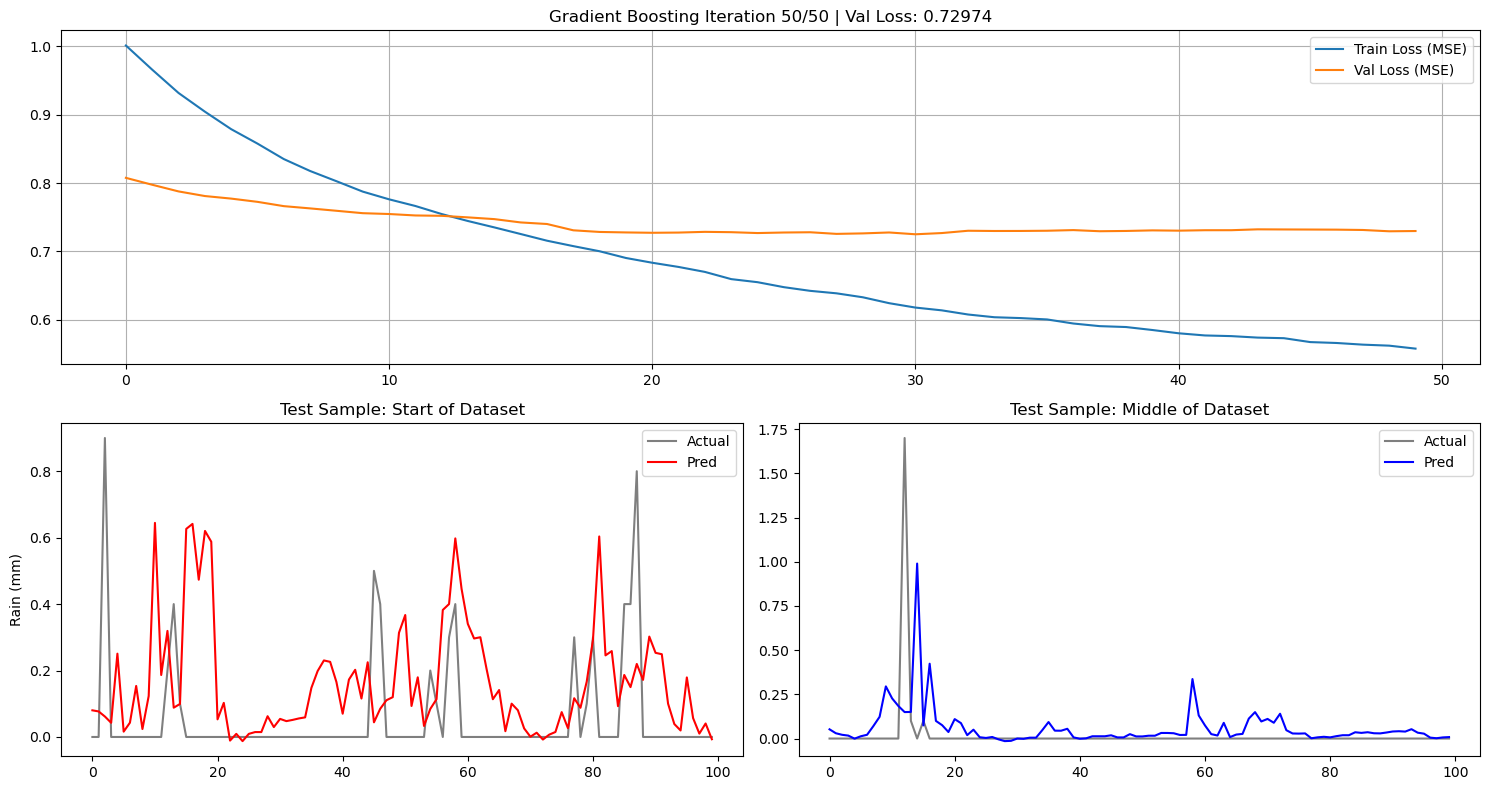

✅ Training Complete.
Final Test MAE: 0.14 mm


In [ ]:


import micropip
await micropip.install(['pandas', 'numpy', 'scikit-learn', 'matplotlib'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyodide.http import pyfetch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor 
from IPython.display import clear_output

%matplotlib inline

# =========================================================
# 1. DATA & FEATURE ENGINEERING
# =========================================================
async def get_hourly_weather():
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=33&longitude=-84&start_date=2022-01-01&end_date=2023-12-31&hourly=rain,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,vapor_pressure_deficit"
    print("Fetching Weather Data...")
    res = await pyfetch(url)
    data = await res.json()
    df = pd.DataFrame(data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    df = df.fillna(method='ffill').fillna(0)
    return df

df = await get_hourly_weather()

# --- Cyclical Time Features ---
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
df["day_sin"]  = np.sin(2 * np.pi * df.index.dayofyear / 366)
df["day_cos"]  = np.cos(2 * np.pi * df.index.dayofyear / 366)

TARGET_COL = "rain"
df['target'] = df[TARGET_COL].shift(-1)
df = df.dropna()

features = [c for c in df.columns if c != 'target']
X_raw = df[features].values
y_raw = df['target'].values.reshape(-1, 1)

# =========================================================
# 2. PCA & SCREE
# =========================================================
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

pca = PCA()
pca.fit(X_scaled)
cum_variance = np.cumsum(pca.explained_variance_ratio_)
n_comps = np.argmax(cum_variance >= 0.95) + 1
X_pca = pca.transform(X_scaled)[:, :n_comps]

# --- PLOT 1: SCREE PLOT ---
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cum_variance)+1), cum_variance, marker='.', linestyle='-')
plt.axhline(0.95, color='red', linestyle='--', label='95% Explained Variance')
plt.axvline(n_comps, color='green', linestyle='--', label=f'Selected Components ({n_comps})')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.legend()
plt.grid(True)
plt.show()

print(f"Selected top {n_comps} components.")

# =========================================================
# 3. SCALING TARGETS & FLATTENING SEQUENCES
# =========================================================
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_raw)

def make_sequences(data, targets, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(targets[i+seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

SEQ_LEN = 36
X_seq, y_seq = make_sequences(X_pca, y_scaled, SEQ_LEN)

########################
# CHANGE FOR TREES
########################
# Trees expect 2D input (Samples, Features).
# currently 3D (Samples, TimeSteps, PCA_Features).
# FLATTEN the TimeSteps and Features into one long vector per sample.

N, T, F = X_seq.shape
X_seq_flat = X_seq.reshape(N, T * F) # Shape becomes (N, 360) for example
y_seq_flat = y_seq.ravel()           # Trees want vector y, not (N,1)

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq_flat[:split], X_seq_flat[split:]
y_train, y_test = y_seq_flat[:split], y_seq_flat[split:]

print(f"Flattened Input Shape: {X_train.shape}")

# =========================================================
# 4. TRAINING LOOP (Simulated Epochs with Warm Start)
# =========================================================

# use HistGradientBoostingRegressor 
# warm_start=True allows incrementally updating the plot.
model = HistGradientBoostingRegressor(
    max_iter=1,         # Start with 1 tree
    warm_start=True,    # Keep adding to it
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=0
)

epochs = 50
history = {'train_loss': [], 'val_loss': []}
logs = []

for epoch in range(epochs):
    # Increase the number of allowed trees (iterations) by 1 each loop
    model.set_params(max_iter=epoch + 1)
    
    # Fit (because of warm_start, this just adds the new tree)
    model.fit(X_train, y_train)
    
    # Calculate Losses (MSE)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_test)
    
    train_loss = np.mean((train_pred - y_train)**2)
    val_loss = np.mean((val_pred - y_test)**2)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Logging
    log_msg = f"Epoch {epoch+1:02d} | Train Loss: {history['train_loss'][-1]:.5f} | Val Loss: {val_loss:.5f}"
    logs.append(log_msg)
    
    clear_output(wait=True)
    print("\n".join(logs))
    
    # --- VISUALIZATION ---
    # Inverse transform predictions for plotting in mm
    preds_scaled = val_pred.reshape(-1, 1)
    y_test_scaled = y_test.reshape(-1, 1)
    
    preds_mm = scaler_y.inverse_transform(preds_scaled)
    y_test_mm = scaler_y.inverse_transform(y_test_scaled)
    
    fig = plt.figure(figsize=(15, 8))
    gs = fig.add_gridspec(2, 2)
    
    # Plot 1: Loss Curves
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(history['train_loss'], label='Train Loss (MSE)')
    ax1.plot(history['val_loss'], label='Val Loss (MSE)')
    ax1.set_title(f"Gradient Boosting Iteration {epoch+1}/{epochs} | Val Loss: {val_loss:.5f}")
    ax1.legend()
    ax1.grid(True)
    
    # Plot 2: Test Sample 1
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(y_test_mm[:100], label='Actual', color='black', alpha=0.5)
    ax2.plot(preds_mm[:100], label='Pred', color='red')
    ax2.set_title("Test Sample: Start of Dataset")
    ax2.set_ylabel("Rain (mm)")
    ax2.legend()
    
    # Plot 3: Test Sample 2
    mid = len(y_test_mm) // 2
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(y_test_mm[mid:mid+100], label='Actual', color='black', alpha=0.5)
    ax3.plot(preds_mm[mid:mid+100], label='Pred', color='blue')
    ax3.set_title("Test Sample: Middle of Dataset")
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

print(f"Training Complete.")
print(f"Final Test MAE: {mean_absolute_error(y_test_mm, preds_mm):.2f} in mm of rainfall")

In [2]:
import time
import asyncio
import array
from pyodide.http import pyfetch

# 1. SETUP: Install FastAPI & Dependencies
import micropip
await micropip.install("fastapi")
from fastapi import FastAPI
from fastapi.responses import JSONResponse

# 2. DEFINE THE APP
app = FastAPI()

@app.get("/benchmark/{item_id}")
async def read_item(item_id: int):
    # Simulate a lightweight backend task
    return {"status": "success", "processed_id": item_id, "timestamp": time.time()}

# 3. MOCK ASGI ADAPTER
# Since we don't have Uvicorn/sockets, we call the app's __call__ directly
async def mock_api_call(path: str):
    scope = {
        "type": "http",
        "method": "GET",
        "path": path,
        "headers": [],
        "query_string": b"",
    }
    
    response_data = []
    async def receive(): return {"type": "http.request"}
    async def send(message):
        if message["type"] == "http.response.body":
            response_data.append(message["body"])

    await app(scope, receive, send)
    return response_data

# 4. ENHANCED BENCHMARK
async def run_resource_test():
    print("--- Pyodide Backend Resource Test ---")

    # CPU: Standard Prime Test
    t0 = time.time()
    sum(range(10**6)) # Simple CPU spike
    print(f"CPU (Sum 1M): {time.time() - t0:.4f}s")

    # RAM: Allocation
    t0 = time.time()
    _ = array.array('d', [1.0] * 5_000_000) # ~40MB
    print(f"RAM (40MB Alloc): {time.time() - t0:.4f}s")

    # FASTAPI: Routing & Middleware Overhead
    # This measures how 'heavy' the FastAPI abstraction is in WASM
    t0 = time.time()
    for _ in range(100):
        await mock_api_call("/benchmark/42")
    avg_latency = (time.time() - t0) / 100
    print(f"FastAPI Avg Latency (100 calls): {avg_latency:.6f}s per request")

    print("\n--- Test Complete ---")

await run_resource_test()

--- Pyodide Backend Resource Test ---
,CPU (Sum 1M): 0.0940s
,RAM (40MB Alloc): 0.3150s
,FastAPI Avg Latency (100 calls): 0.000220s per request
,
,--- Test Complete ---


In [3]:
import numpy as np
import gc
import time

def memory_limit_test():
    print("--- Pyodide Memory Limit Test ---")
    print("Targeting: Simulated Image Data (float32)")
    
    allocations = []
    total_mb = 0
    
    # We increase in steps of 256MB
    step_mb = 256 
    
    try:
        for i in range(1, 20): # Try up to ~5GB (which will definitely fail)
            print(f"\nAttempting to allocate additional {step_mb}MB...")
            
            # Create a 'large image' block
            # float32 uses 4 bytes per element. 
            # (step_mb * 1024 * 1024) / 4 = number of elements
            elements = (step_mb * 1024 * 1024) // 4
            new_block = np.ones(elements, dtype=np.float32)
            
            allocations.append(new_block)
            total_mb += step_mb
            
            print(f"Current Total: {total_mb}MB across {len(allocations)} blocks")
            
    except MemoryError:
        print("\n[!] CAUGHT: Python MemoryError.")
        print(f"Max stable allocation reached: {total_mb}MB")
    except Exception as e:
        print(f"\n[!] Unexpected Error: {e}")
    finally:
        # Clean up to prevent the tab from staying 'heavy'
        print("Cleaning up memory...")
        del allocations
        gc.collect()
        print("Done.")

# Run the test
memory_limit_test()

--- Pyodide Memory Limit Test ---
,Targeting: Simulated Image Data (float32)
,
,Attempting to allocate additional 256MB...
,Current Total: 256MB across 1 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 512MB across 2 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 768MB across 3 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 1024MB across 4 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 1280MB across 5 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 1536MB across 6 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 1792MB across 7 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 2048MB across 8 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 2304MB across 9 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 2560MB across 10 blocks
,
,Attempting to allocate additional 256MB...
,Current Total: 2816MB across

In [4]:
import time

def pystone(loops=50000):
    # This is a simplified version of the standard pystone test
    # optimized for browser-based environments.
    
    def check_logic(i):
        # Mixed operations: attribute access, math, and logic
        a = i * 2
        b = a / 2
        return a == b

    print(f"Running {loops} loops...")
    start_time = time.time()
    
    for i in range(loops):
        _ = check_logic(i)
        _ = list(range(10)) # Small allocation
        
    end_time = time.time()
    duration = end_time - start_time
    pystones_per_sec = loops / duration
    
    print(f"\n--- Single Core Result ---")
    print(f"Time: {duration:.4f} seconds")
    print(f"Score: {pystones_per_sec:.2f} pystones/second")
    return pystones_per_sec

await pystone()

Running 50000 loops...
,
,--- Single Core Result ---
,Time: 0.0520 seconds
,Score: 961537.62 pystones/second


<class 'TypeError'>: object float can't be used in 'await' expression

In [6]:
import micropip
await micropip.install("fastapi")

from fastapi import FastAPI
from fastapi.responses import HTMLResponse

app = FastAPI()

# Your HTML from the uploaded ls.html
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>USGS Landsat Imagery</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <style>#map { height: 600px; width: 100%; }</style>
</head>
<body>
    <h1>USGS Landsat Imagery (Pyodide Backend)</h1>
    <div id="map"></div>
    <script>
        const map = L.map('map').setView([37.8, -96], 4);
        L.tileLayer('https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}', {
            maxZoom: 20, attribution: 'USGS'
        }).addTo(map);
    </script>
</body>
</html>
"""

@app.get("/", response_class=HTMLResponse)
async def read_root():
    return html_content

async def simulate_request(path: str):
    # Added missing ASGI keys: query_string, server, client, scheme
    scope = {
        "type": "http",
        "http_version": "1.1",
        "method": "GET",
        "path": path,
        "raw_path": path.encode(),
        "query_string": b"", 
        "headers": [(b"accept", b"text/html")],
        "server": ("127.0.0.1", 80),
        "client": ("127.0.0.1", 54321),
        "scheme": "http",
    }
    
    response_body = []
    
    async def receive():
        return {"type": "http.request"}
        
    async def send(message):
        if message["type"] == "http.response.body":
            response_body.append(message["body"].decode())

    # This calls the FastAPI app logic directly
    await app(scope, receive, send)
    return "".join(response_body)

# Run the test
print("--- Launching Pyodide Static Host ---")
try:
    page_output = await simulate_request("/")
    print(f"Success! Response Length: {len(page_output)} characters")
    print("\nPreview of rendered HTML:")
    print(page_output[:150] + "...")
except Exception as e:
    print(f"Failed with error: {e}")

--- Launching Pyodide Static Host ---
,Success! Response Length: 783 characters
,
,Preview of rendered HTML:
,
,<!DOCTYPE html>
,<html lang="en">
,<head>
,    <meta charset="UTF-8">
,    <meta name="viewport" content="width=device-width, initial-scale=1.0">
,    <ti...


In [12]:
import micropip
await micropip.install("fastapi")

from fastapi import FastAPI
from fastapi.responses import HTMLResponse
from IPython.display import display, HTML
import html

# 1. DEFINE FASTAPI APP
app = FastAPI()

# Note: Added 'width: 100vw; height: 100vh;' to body to ensure full frame fill
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>USGS Landsat Imagery</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <style>
        body { margin: 0; padding: 0; width: 100vw; height: 100vh; overflow: hidden; }
        #map { height: 100%; width: 100%; }
    </style>
</head>
<body>
    <div id="map"></div>
    <script>
        var map = L.map('map').setView([37.8, -96], 4);
        L.tileLayer('https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}', {
            maxZoom: 20,
            attribution: 'USGS'
        }).addTo(map);
    </script>
</body>
</html>
"""

@app.get("/", response_class=HTMLResponse)
async def read_root():
    return html_content

# 2. SERVER SIMULATION
async def simulate_request(path):
    scope = {
        "type": "http",
        "http_version": "1.1",
        "method": "GET",
        "path": path,
        "raw_path": path.encode(),
        "query_string": b"", 
        "headers": [(b"accept", b"text/html")],
        "server": ("127.0.0.1", 80),
        "client": ("127.0.0.1", 54321),
        "scheme": "http",
    }
    response_body = []
    async def receive(): return {"type": "http.request"}
    async def send(message):
        if message["type"] == "http.response.body":
            response_body.append(message["body"].decode())
    await app(scope, receive, send)
    return "".join(response_body)

# 3. THE "PROXY" RENDERER
async def render_proxy():
    print("Fetching HTML from FastAPI backend...")
    raw_html = await simulate_request("/")
    
    # ESCAPE the HTML so it can sit safely inside a srcdoc string
    escaped_html = html.escape(raw_html)
    
    # Create an iframe that carries its own source code
    # This tricks the browser into rendering it as a fresh page
    iframe_code = f"""
    <iframe 
        srcdoc="{escaped_html}" 
        style="width: 100%; height: 600px; border: 2px solid #ccc;"
        sandbox="allow-scripts allow-same-origin allow-forms"
    ></iframe>
    """
    
    print("Proxy active. Rendering secure frame...")
    display(HTML(iframe_code))

await render_proxy()

Fetching HTML from FastAPI backend...
,Proxy active. Rendering secure frame...


In [13]:
import micropip
import html
from IPython.display import display, HTML

# 1. HEAVY INSTALL (Run once)
print("--- Installing Geospatial Stack (this may take 1-2 mins) ---")
try:
    # Basic server deps
    await micropip.install("fastapi")
    # Data & Plotting deps
    await micropip.install(["pandas", "geopandas", "plotly", "mapclassify", "folium", "matplotlib"])
    print("Installation Complete!")
except Exception as e:
    print(f"Install warning (packages might already be present): {e}")

# 2. IMPORTS
from fastapi import FastAPI
from fastapi.responses import HTMLResponse
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import plotly.express as px
import plotly.io as pio

# Set Plotly to render for browser
pio.renderers.default = 'browser'

app = FastAPI()

# --- ENDPOINT 1: PLOTLY 3D GLOBE ---
@app.get("/plotly", response_class=HTMLResponse)
async def get_plotly_map():
    # Create a simple dataset
    df = pd.DataFrame({
        "City": ["New York", "London", "Tokyo", "Sydney", "Pyodide HQ"],
        "Lat": [40.7128, 51.5074, 35.6762, -33.8688, 0.0],
        "Lon": [-74.0060, -0.1278, 139.6503, 151.2093, 0.0],
        "Size": [10, 10, 10, 10, 20]
    })
    
    # Generate 3D Scatter Plot
    fig = px.scatter_geo(
        df, lat="Lat", lon="Lon", size="Size", hover_name="City",
        projection="orthographic", # Makes it a 3D globe
        title="Plotly 3D Globe via Pyodide"
    )
    
    # Convert to HTML (include_plotlyjs='cdn' keeps the file size small)
    return fig.to_html(include_plotlyjs="cdn", full_html=True)

# --- ENDPOINT 2: GEOPANDAS .EXPLORE() ---
@app.get("/geopandas", response_class=HTMLResponse)
async def get_geopandas_map():
    # Create synthetic GeoDataFrame
    d = {'col1': ['name1', 'name2'], 'geometry': [Point(10, 10), Point(20, 20)]}
    gdf = gpd.GeoDataFrame(d, crs="EPSG:4326")
    
    # Buffer points to create polygons (geometry manipulation test)
    gdf['geometry'] = gdf.geometry.buffer(5)
    
    # .explore() returns a Folium map object
    m = gdf.explore(color="red", style_kwds={'fillOpacity': 0.4})
    
    # Get HTML string from the Folium map
    return m.get_root().render()

# --- SERVER SIMULATOR ---
async def simulate_request(path):
    scope = {
        "type": "http", "http_version": "1.1", "method": "GET",
        "path": path, "raw_path": path.encode(), "query_string": b"",
        "headers": [(b"accept", b"text/html")],
        "server": ("127.0.0.1", 80), "client": ("127.0.0.1", 54321), "scheme": "http",
    }
    response_body = []
    async def receive(): return {"type": "http.request"}
    async def send(message):
        if message["type"] == "http.response.body":
            response_body.append(message["body"].decode())
    await app(scope, receive, send)
    return "".join(response_body)

# --- THE PROXY RENDERER ---
async def show_map(endpoint="/plotly"):
    print(f"Requesting {endpoint} from Backend...")
    raw_html = await simulate_request(endpoint)
    
    # Sanitize and Wrap
    escaped_html = html.escape(raw_html)
    iframe_code = f"""
    <iframe 
        srcdoc="{escaped_html}" 
        style="width: 100%; height: 500px; border: 1px solid #ccc; border-radius: 8px;"
        sandbox="allow-scripts allow-same-origin allow-popups allow-forms"
    ></iframe>
    """
    display(HTML(f"<h3>Rendering: {endpoint}</h3>"))
    display(HTML(iframe_code))

# RUN TEST: Change to "/geopandas" to test the other library
await show_map("/plotly")

--- Installing Geospatial Stack (this may take 1-2 mins) ---
,Install warning (packages might already be present): Can't find a pure Python 3 wheel for 'pyproj>=3.5.0'.
,See: https://pyodide.org/en/stable/usage/faq.html#why-can-t-micropip-find-a-pure-python-wheel-for-a-package
,You can use `await micropip.install(..., keep_going=True)` to get a list of all packages with missing wheels.


<class 'ModuleNotFoundError'>: No module named 'geopandas'

In [14]:
import micropip
import html
from IPython.display import display, HTML

# 1. LIGHTER INSTALL
print("--- Installing Plotly Stack ---")
try:
    # We only need these three. No heavy C-extensions like GDAL.
    await micropip.install(["fastapi", "plotly", "pandas"])
    print("Installation Complete!")
except Exception as e:
    print(f"Install warning: {e}")

from fastapi import FastAPI
from fastapi.responses import HTMLResponse
import plotly.express as px
import pandas as pd
import numpy as np

app = FastAPI()

# 2. THE PLOTLY ENDPOINT
@app.get("/viz", response_class=HTMLResponse)
async def get_visualization():
    # TEST GOAL: Generate 1000 points of 3D data (CPU Test)
    # This proves your backend can do math before serving
    t = np.linspace(0, 10, 1000)
    df = pd.DataFrame({
        "x": np.cos(t),
        "y": np.sin(t),
        "z": t,
        "color": t
    })
    
    # Create 3D Helix (Data Visualization)
    fig = px.scatter_3d(
        df, x='x', y='y', z='z', color='color',
        title="Server-Generated 3D Helix",
        template="plotly_dark"
    )
    
    # Optimization: 'cdn' loads the JS from internet, keeping your server response small
    return fig.to_html(include_plotlyjs="cdn", full_html=True)

# 3. SERVER SIMULATOR (Standard boilerplate)
async def simulate_request(path):
    scope = {
        "type": "http", "http_version": "1.1", "method": "GET",
        "path": path, "raw_path": path.encode(), "query_string": b"",
        "headers": [(b"accept", b"text/html")],
        "server": ("127.0.0.1", 80), "client": ("127.0.0.1", 54321), "scheme": "http",
    }
    response_body = []
    async def receive(): return {"type": "http.request"}
    async def send(message):
        if message["type"] == "http.response.body":
            response_body.append(message["body"].decode())
    await app(scope, receive, send)
    return "".join(response_body)

# 4. SECURE PROXY RENDERER
async def render_plotly():
    print("Requesting 3D Viz from Backend...")
    raw_html = await simulate_request("/viz")
    
    print(f"Received {len(raw_html)} bytes. Rendering...")
    
    escaped_html = html.escape(raw_html)
    iframe_code = f"""
    <iframe 
        srcdoc="{escaped_html}" 
        style="width: 100%; height: 600px; border: 1px solid #444; border-radius: 4px;"
        sandbox="allow-scripts allow-same-origin"
    ></iframe>
    """
    display(HTML(iframe_code))

await render_plotly()

--- Installing Plotly Stack ---
,Installation Complete!
,Requesting 3D Viz from Backend...
,Received 59692 bytes. Rendering...
